 Image loaded. Processing
SSD (Nearest): 0.01020
SSD (Bilinear): 0.00562


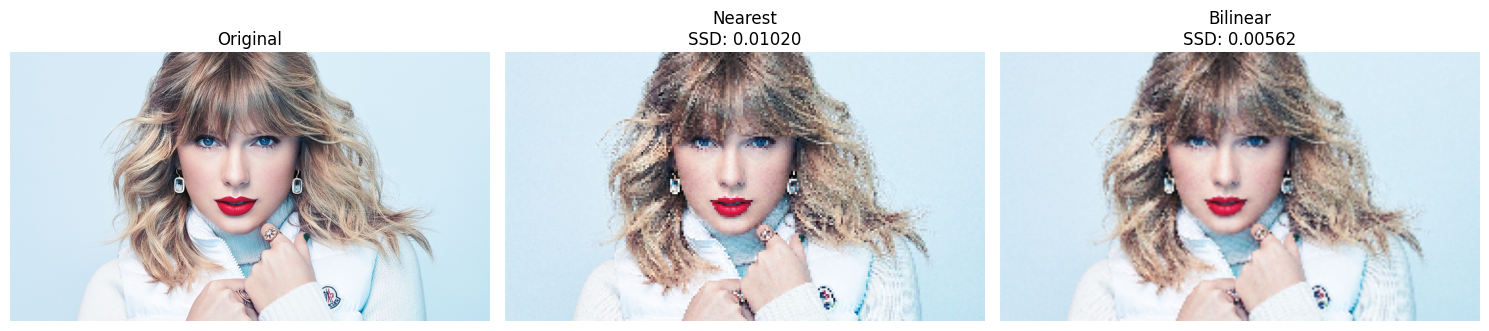

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


# Manual Nearest Neighbor Zoom Function
def nearest_neighbor_zoom(img , scale):
    h , w = img.shape[:2]
    new_h , new_w = int(h * scale) , int(w * scale)

    # Create grid for new image
    x_new = np.arange(new_w)
    y_new = np.arange(new_h)

    # Find corresponding coordinates in old image
    x_old = (x_new / scale).astype(int)
    y_old = (y_new / scale).astype(int)

    # Clip to bounds to avoid errors at edges
    x_old = np.clip(x_old , 0 , w - 1)
    y_old = np.clip(y_old , 0 , h - 1)

    # Vectorized mapping
    xv , yv = np.meshgrid(x_old , y_old)
    return img[yv , xv]


#  2. Manual Bilinear Zoom Function
def bilinear_zoom(img , scale):
    h , w = img.shape[:2]
    new_h , new_w = int(h * scale) , int(w * scale)

    # Coordinate mapping (float)
    x_src = np.arange(new_w) / scale
    y_src = np.arange(new_h) / scale
    x_grid , y_grid = np.meshgrid(x_src , y_src)

    # Get integer coordinates of 4 corners
    x1 = np.floor(x_grid).astype(int)
    y1 = np.floor(y_grid).astype(int)
    x2 = np.clip(x1 + 1 , 0 , w - 1)
    y2 = np.clip(y1 + 1 , 0 , h - 1)
    x1 = np.clip(x1 , 0 , w - 1)
    y1 = np.clip(y1 , 0 , h - 1)

    # Calculate weights
    alpha = x_grid - x1
    beta = y_grid - y1

    # Fix for Color: Expand dimensions
    if img.ndim == 3:
        alpha = alpha[... , None]
        beta = beta[... , None]

    # Get pixel values
    A = img[y1 , x1]
    B = img[y1 , x2]
    C = img[y2 , x1]
    D = img[y2 , x2]

    # Interpolate
    top = (1 - alpha) * A + alpha * B
    bottom = (1 - alpha) * C + alpha * D
    final = (1 - beta) * top + beta * bottom

    return final.astype(np.uint8)


#   SSD Calculation
def compute_ssd(img1 , img2):
    # Crop to match dimensions
    h = min(img1.shape[0] , img2.shape[0])
    w = min(img1.shape[1] , img2.shape[1])

    img1 = img1[:h , :w]
    img2 = img2[:h , :w]

    diff = img1.astype(float) - img2.astype(float)
    # Normalize by sum of squared pixels
    return np.sum(diff ** 2) / np.sum(img1.astype(float) ** 2)



#  Load Taylor Swift Image
file_path = r"d:\computer_Vision_Inclass_11_26\taylor.jpg"
img = cv.imread(file_path)

if img is None:
    print(" ERROR: Could not find taylor.jpg.")
else:
    print(" Image loaded. Processing")

    small = cv.resize(img , None , fx=0.25 , fy=0.25 , interpolation=cv.INTER_NEAREST)
    zoom_nn = nearest_neighbor_zoom(small , 4)
    zoom_bl = bilinear_zoom(small , 4)

    # Compare (SSD)
    ssd_nn = compute_ssd(img , zoom_nn)
    ssd_bl = compute_ssd(img , zoom_bl)

    print(f"SSD (Nearest): {ssd_nn:.5f}")
    print(f"SSD (Bilinear): {ssd_bl:.5f}")

    #Display Results
    plt.figure(figsize=(15 , 6))

    # Original
    plt.subplot(1 , 3 , 1)
    plt.imshow(cv.cvtColor(img , cv.COLOR_BGR2RGB))
    plt.title('Original')
    plt.axis('off')

    # Nearest Neighbor
    plt.subplot(1 , 3 , 2)
    plt.imshow(cv.cvtColor(zoom_nn , cv.COLOR_BGR2RGB))
    plt.title(f'Nearest\nSSD: {ssd_nn:.5f}')
    plt.axis('off')

    # Bilinear
    plt.subplot(1 , 3 , 3)
    plt.imshow(cv.cvtColor(zoom_bl , cv.COLOR_BGR2RGB))
    plt.title(f'Bilinear\nSSD: {ssd_bl:.5f}')
    plt.axis('off')

    plt.tight_layout()
    plt.show()